# CART + SMOTE — Árbol de decisión con Cost-Complexity Pruning

## I. Librerías

In [3]:
# ============================================================
# Librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)
from sklearn.inspection import permutation_importance

# Oversampling
from imblearn.over_sampling import SMOTE

## II. Carga y limpieza de datos

In [ ]:
import os
DATASETS = glob.glob(os.path.join("dataset", "*.csv"))
print(DATASETS) 


dfs = [pd.read_csv(path) for path in DATASETS]
df = pd.concat(dfs, ignore_index=True)

['C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Tuesday-WorkingHours.pcap_ISCX.csv']


### CLEAN DATA

In [5]:

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# Separar features y target
X = df.drop("Label", axis=1)
y = df["Label"]

# Reemplazar infinitos y eliminar NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()
y = y[X.index]

print(f"Dataset: {X.shape[0]:,} filas × {X.shape[1]} columnas")
print("Clases:\n", y.value_counts())

Dataset: 1,606,989 filas × 78 columnas
Clases:
 Label
BENIGN                        1302156
PortScan                       158804
DDoS                           128025
FTP-Patator                      7935
SSH-Patator                      5897
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Name: count, dtype: int64


## III. División train / test

La partición se realiza antes de aplicar SMOTE 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.7,
    random_state=1234,
    shuffle=True,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Train: 1,124,892 | Test: 482,097


## IV. Balanceo de clases con SMOTE

SMOTE genera muestras sintéticas para las clases minoritarias hasta alcanzar el umbral . Se aplica únicamente sobre el conjunto de train

In [7]:
y_train_1d = np.ravel(y_train)
counts = Counter(y_train_1d)

print("Distribución ANTES de SMOTE:")
print(counts)

# Submuestrear hasta cap solo las clases que estén por debajo
cap = 10_000
sampling_dict = {cls: cap for cls, c in counts.items() if c < cap}
print("Sampling strategy:", sampling_dict)

# k_neighbors seguro (no puede superar min_class - 1)
min_class = min(counts.values())
k = min(3, max(1, min_class - 1))
print(f"k_neighbors = {k}")

sm = SMOTE(sampling_strategy=sampling_dict, random_state=2, k_neighbors=k)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train_1d)

print("Distribución DESPUÉS de SMOTE:")
print(Counter(y_train_res))
print(f"Shape train tras SMOTE: {X_train_res.shape}")

Distribución ANTES de SMOTE:
Counter({'BENIGN': 911509, 'PortScan': 111163, 'DDoS': 89617, 'FTP-Patator': 5555, 'SSH-Patator': 4128, 'Bot': 1369, 'Web Attack � Brute Force': 1055, 'Web Attack � XSS': 456, 'Infiltration': 25, 'Web Attack � Sql Injection': 15})
Sampling strategy: {'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Bot': 10000, 'Web Attack � Brute Force': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000}
k_neighbors = 3
Distribución DESPUÉS de SMOTE:
Counter({'BENIGN': 911509, 'PortScan': 111163, 'DDoS': 89617, 'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Bot': 10000, 'Web Attack � Brute Force': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000})
Shape train tras SMOTE: (1182289, 78)


## V. Reducción de muestras para búsqueda de hiperparámetros


In [ ]:
# Muestra estratificada de 10 000 filas : se usa SOLO para buscar el mejor alpha
X_train_s, _, y_train_s, _ = train_test_split(
    X_train_res, y_train_res,
    train_size=10_000,
    stratify=y_train_res,
    random_state=42
)

print(f"Muestra reducida: {X_train_s.shape}")
print(pd.Series(y_train_s).value_counts())

Muestra reducida: (10000, 78)
BENIGN                        7710
PortScan                       940
DDoS                           758
FTP-Patator                     85
Web Attack � Sql Injection      85
Bot                             85
Infiltration                    85
SSH-Patator                     84
Web Attack � Brute Force        84
Web Attack � XSS                84
Name: count, dtype: int64


## VI. Cost-Complexity Pruning (CCP)


Buscamoss el parámetro de penalización: --> *Error total = Error en training + α × número de hojas**


### Estrategia en dos pasos

Paso 1 : Exploración: calcular el rango real de alphas a partir de una muestra de 100 k filas


Paso 2 : GridSearchCV fino: evaluar 20 alphas en escala logarítmica con CV y métrica F1-macro 

### Si  devuelve α = 0

Cuando el mejor alpha es 0, el árbol queda sin poda. Esto puede ocurrir si:
- Los datos son suficientemente limpios y el árbol profundo no sobreajusta en CV.
- Las separaciones de clase son muy marcadas

En ese caso, se evalúa si la profundidad y el número de hojas son razonables. Si el árbol resulta excesivamente grande, se fuerza un alpha mínimo porque sino puede provocar overfitting.

In [ ]:
# ============================================================
# PASO 1: Calcular rango de alphas sobre muestra grande (100k)
# ============================================================
X_path, _, y_path, _ = train_test_split(
    X_train_res, y_train_res,
    train_size=100_000,
    stratify=y_train_res,
    random_state=99
)

fulltree_path = DecisionTreeClassifier(random_state=2)
fulltree_path.fit(X_path, y_path)

path = fulltree_path.cost_complexity_pruning_path(X_path, y_path)
raw_alphas = path.ccp_alphas

# Descartar alpha=0 y valores extremadamente pequeños (< 1e-5)
raw_alphas = raw_alphas[raw_alphas > 1e-5]

# 20 alphas en escala logarítmica 
alphas_grid = np.geomspace(raw_alphas.min(), raw_alphas.max(), num=20)

print(f"Rango de alphas explorado: {alphas_grid.min():.2e}  →  {alphas_grid.max():.2e}")
print(f"Alphas a evaluar ({len(alphas_grid)}):")
print(np.round(alphas_grid, 6))

Rango de alphas explorado: 1.13e-05  →  7.37e-02
Alphas a evaluar (20):
[1.1000e-05 1.8000e-05 2.8000e-05 4.5000e-05 7.2000e-05 1.1400e-04
 1.8100e-04 2.8700e-04 4.5600e-04 7.2400e-04 1.1490e-03 1.8240e-03
 2.8970e-03 4.6000e-03 7.3030e-03 1.1596e-02 1.8412e-02 2.9235e-02
 4.6419e-02 7.3703e-02]


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejor alpha (GridSearchCV): 0.000287
F1-macro CV con ese alpha:  0.8799
Top 10 alphas por F1-macro:
   alpha  mean_f1   std_f1
0.000287 0.879856 0.020301
0.000456 0.872202 0.012881
0.000011 0.870170 0.016128
0.000018 0.870170 0.016128
0.000045 0.870170 0.016128
0.000028 0.870170 0.016128
0.000072 0.870170 0.016128
0.000114 0.868952 0.014405
0.000181 0.868383 0.016459
0.000724 0.862640 0.013363


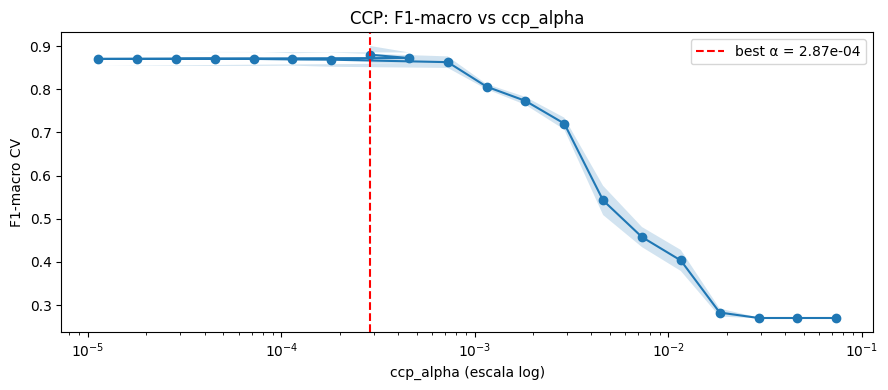

In [ ]:
# ============================================================
# PASO 2: GridSearchCV sobre la muestra pequeña 
# CV=3, scoring=f1_macro 
# ============================================================
param_grid = {'ccp_alpha': alphas_grid}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1_macro',
    verbose=1
)
grid.fit(X_train_s, y_train_s)

best_alpha = grid.best_params_['ccp_alpha']
print(f"Mejor alpha (GridSearchCV): {best_alpha:.6f}")
print(f"F1-macro CV con ese alpha:  {grid.best_score_:.4f}")

# Tabla completa de resultados
results_df = pd.DataFrame({
    'alpha':    alphas_grid,
    'mean_f1':  grid.cv_results_['mean_test_score'],
    'std_f1':   grid.cv_results_['std_test_score']
}).sort_values('mean_f1', ascending=False)

print("Top 10 alphas por F1-macro:")
print(results_df.head(10).to_string(index=False))

# Gráfico alpha vs F1
plt.figure(figsize=(9, 4))
plt.semilogx(results_df['alpha'], results_df['mean_f1'], marker='o')
plt.fill_between(results_df['alpha'],
                 results_df['mean_f1'] - results_df['std_f1'],
                 results_df['mean_f1'] + results_df['std_f1'],
                 alpha=0.2)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'best α = {best_alpha:.2e}')
plt.xlabel("ccp_alpha (escala log)")
plt.ylabel("F1-macro CV")
plt.title("CCP: F1-macro vs ccp_alpha")
plt.legend()
plt.tight_layout()
plt.show()

## VII. Entrenamiento del modelo final

Con el  k seleccionado, se entrena el árbol sobre todos los datos SMOTE, no sobre la muestra reducida. Esto garantiza que el modelo final aproveche toda la información disponible.

In [12]:
model_final = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=0)
model_final.fit(X_train_res, y_train_res)

print(f"Árbol final entrenado sobre {X_train_res.shape[0]:,} muestras")
print(f"Profundidad:      {model_final.get_depth()}")
print(f"Número de hojas:  {model_final.get_n_leaves()}")

if model_final.get_depth() > 30 or model_final.get_n_leaves() > 1000:
    print("El árbol es muy complejo. Considera aumentar ccp_alpha para reducir")
    print("   la complejidad y mejorar la interpretabilidad.")
else:
    print("Complejidad del árbol razonable.")

Árbol final entrenado sobre 1,182,289 muestras
Profundidad:      13
Número de hojas:  53
Complejidad del árbol razonable.


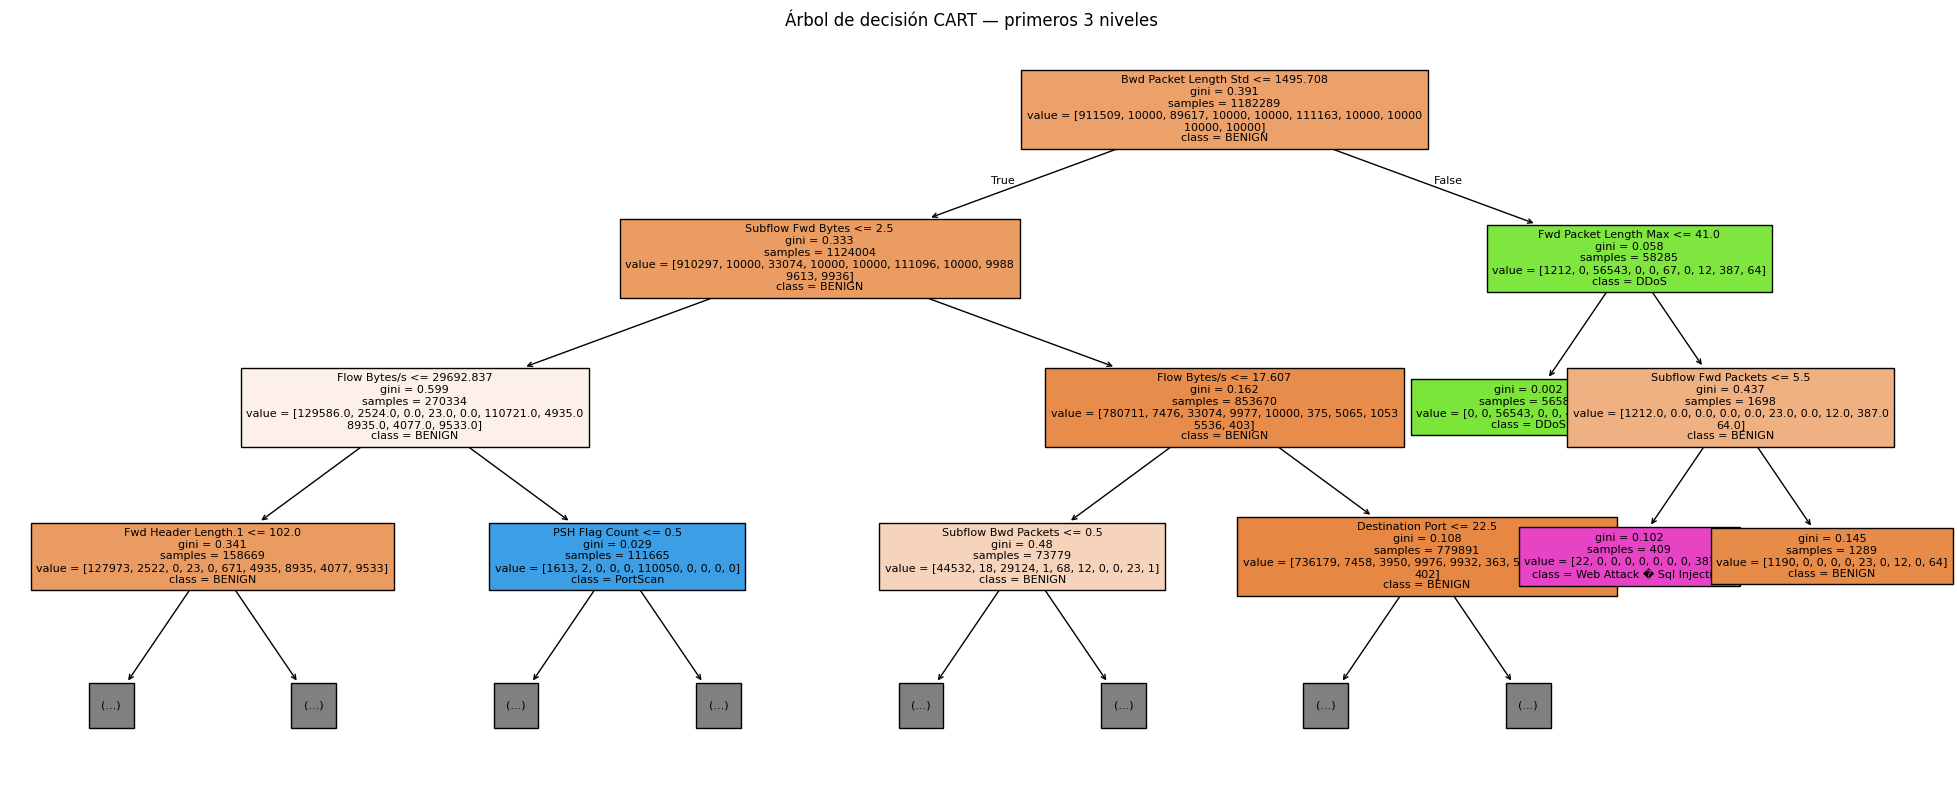

|--- Bwd Packet Length Std <= 1495.71
|   |--- Subflow Fwd Bytes <= 2.50
|   |   |--- Flow Bytes/s <= 29692.84
|   |   |   |--- Fwd Header Length.1 <= 102.00
|   |   |   |   |--- truncated branch of depth 7
|   |   |   |--- Fwd Header Length.1 >  102.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- Flow Bytes/s >  29692.84
|   |   |   |--- PSH Flag Count <= 0.50
|   |   |   |   |--- class: BENIGN
|   |   |   |--- PSH Flag Count >  0.50
|   |   |   |   |--- class: PortScan
|   |--- Subflow Fwd Bytes >  2.50
|   |   |--- Flow Bytes/s <= 17.61
|   |   |   |--- Subflow Bwd Packets <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Subflow Bwd Packets >  0.50
|   |   |   |   |--- class: BENIGN
|   |   |--- Flow Bytes/s >  17.61
|   |   |   |--- Destination Port <= 22.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- Destination Port >  22.50
|   |   |   |   |--- truncated branch of depth 10
|--- Bwd Packet Length Std >  1495.71
|   |

In [13]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(20, 8))
plot_tree(model_final,
          max_depth=3,
          feature_names=X_train_res.columns.tolist(),
          class_names=sorted(np.unique(y_train_res)),
          filled=True,
          fontsize=8)
plt.title("Árbol de decisión CART — primeros 3 niveles")
plt.tight_layout()
plt.show()

print(export_text(model_final,
                  feature_names=X_train_res.columns.tolist(),
                  max_depth=3))

## VIII. Evaluación del modelo final

### 8.1 Evaluación en train

Evaluamos primero en train para detectar sobreajuste. Si la accuracy de train es mucho mayor que la de test, hay overfitting.

Accuracy train: 98.78 %

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    911509
                       Bot       0.90      0.89      0.90     10000
                      DDoS       1.00      0.99      1.00     89617
               FTP-Patator       1.00      1.00      1.00     10000
              Infiltration       0.98      0.90      0.94     10000
                  PortScan       0.99      0.99      0.99    111163
               SSH-Patator       1.00      0.99      0.99     10000
  Web Attack � Brute Force       0.73      0.38      0.50     10000
Web Attack � Sql Injection       0.93      0.94      0.94     10000
          Web Attack � XSS       0.60      0.85      0.70     10000

                  accuracy                           0.99   1182289
                 macro avg       0.91      0.89      0.89   1182289
              weighted avg       0.99      0.99      0.99   1182289



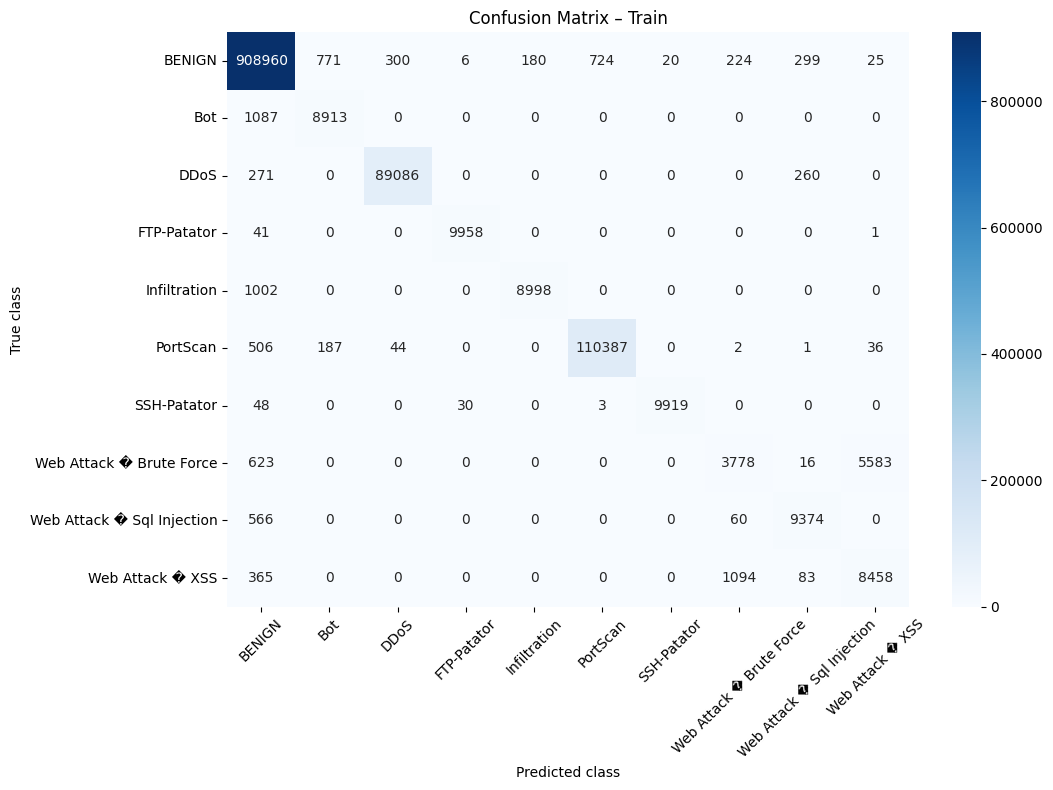

In [14]:
predictions_train = model_final.predict(X_train_res)

print("Accuracy train: {:.2f} %".format(100 * accuracy_score(y_train_res, predictions_train)))
print()
print(classification_report(y_train_res, predictions_train))

labels = sorted(np.unique(y_train_res))
cm_train = confusion_matrix(y_train_res, predictions_train, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix – Train")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8.2 Evaluación en test

El conjunto de test no ha intervenido en ninguna fase de entrenamiento ni selección de hiperparámetros, por lo que representa el rendimiento real esperado.

Accuracy test: 99.58 %

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    390647
                       Bot       0.54      0.89      0.68       587
                      DDoS       1.00      0.99      0.99     38408
               FTP-Patator       1.00      1.00      1.00      2380
              Infiltration       0.09      0.55      0.15        11
                  PortScan       0.99      0.99      0.99     47641
               SSH-Patator       1.00      0.99      0.99      1769
  Web Attack � Brute Force       0.63      0.38      0.47       452
Web Attack � Sql Injection       0.01      0.50      0.03         6
          Web Attack � XSS       0.37      0.85      0.52       196

                  accuracy                           1.00    482097
                 macro avg       0.66      0.81      0.68    482097
              weighted avg       1.00      1.00      1.00    482097



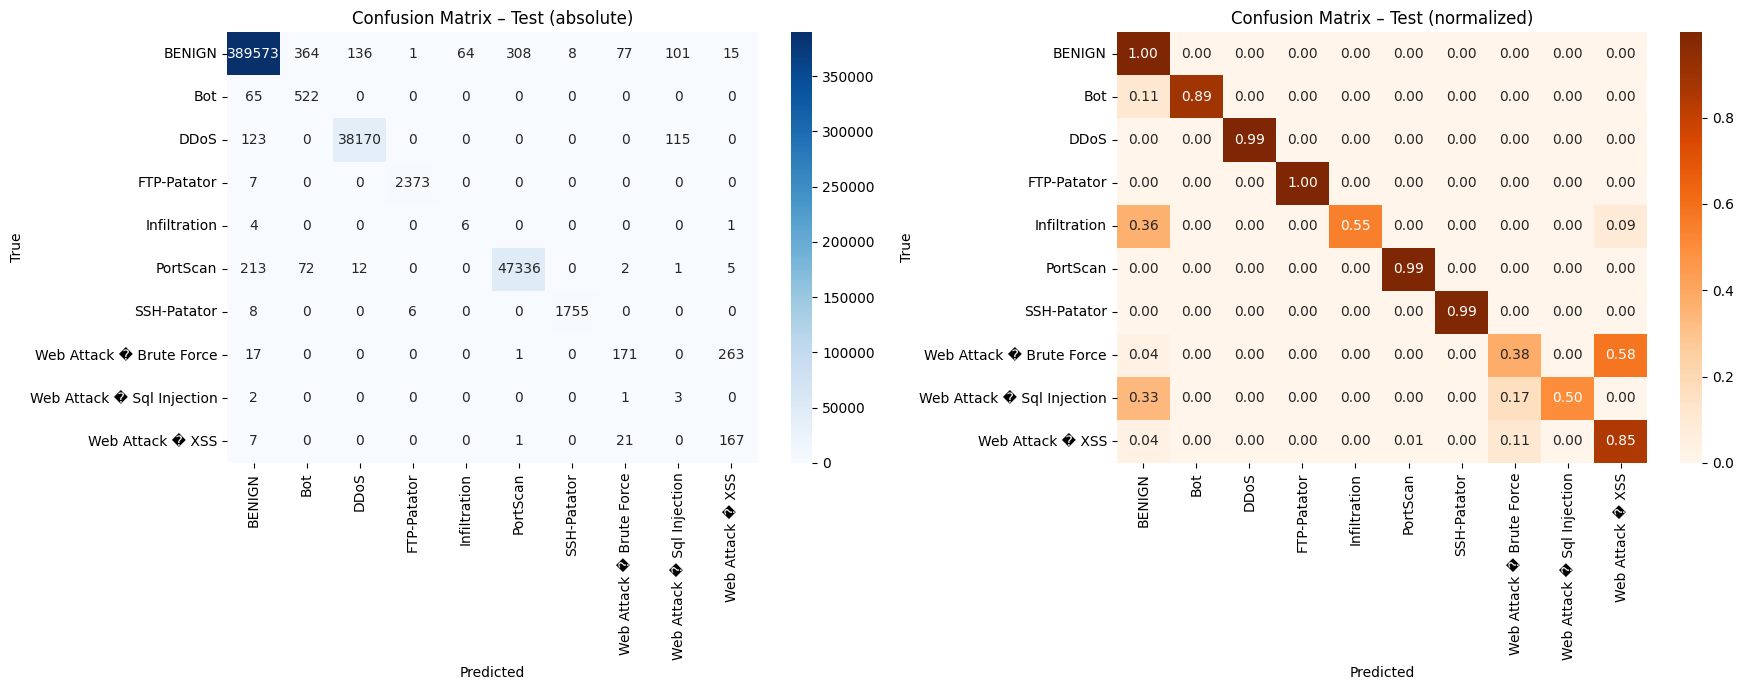

In [15]:
pred_test = model_final.predict(X_test)

print("Accuracy test: {:.2f} %".format(100 * accuracy_score(y_test, pred_test)))
print()
print(classification_report(y_test, pred_test))

labels_test = sorted(np.unique(y_test))
cm_test = confusion_matrix(y_test, pred_test, labels=labels_test)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_test, yticklabels=labels_test, ax=axes[0])
axes[0].set_title("Confusion Matrix – Test (absolute)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

cm_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=labels_test, yticklabels=labels_test, ax=axes[1])
axes[1].set_title("Confusion Matrix – Test (normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.show()

## IX. Importancia de variables (Permutation Importance)

La importancia de Gini nativa del árbol puede sobreestimar variables con alta cardinalidad.  es más robusta: mide cuánto cae el F1-macro al permutar aleatoriamente cada variable en el conjunto de test.

- **Valor alto** :  la variable es crítica para el modelo.  
- **Valor negativo** : la variable puede añadir ruido 

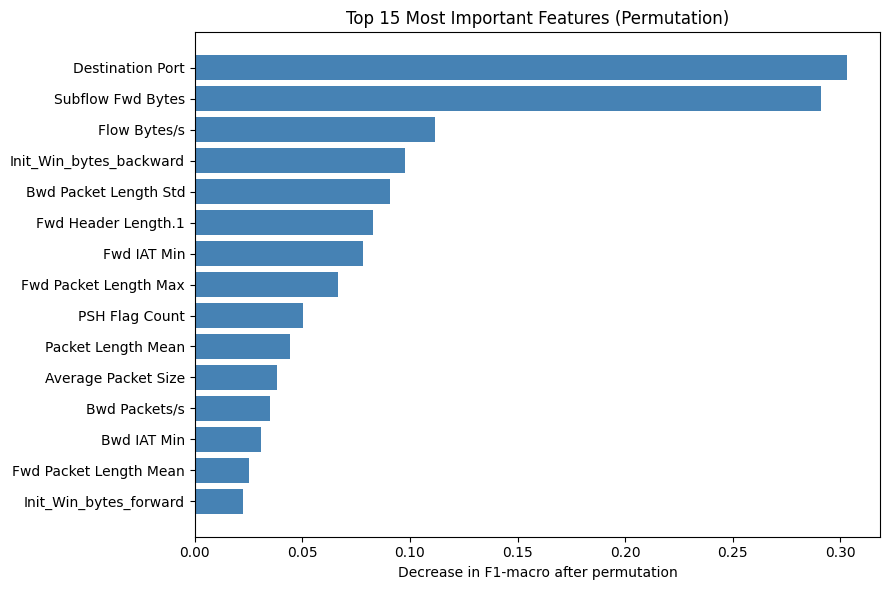

Top 20 variables por importancia:
                    Feature  Importance
           Destination Port    0.303303
          Subflow Fwd Bytes    0.290922
               Flow Bytes/s    0.111519
    Init_Win_bytes_backward    0.097487
      Bwd Packet Length Std    0.090719
        Fwd Header Length.1    0.082651
                Fwd IAT Min    0.078147
      Fwd Packet Length Max    0.066401
             PSH Flag Count    0.050449
         Packet Length Mean    0.044065
        Average Packet Size    0.037971
              Bwd Packets/s    0.035020
                Bwd IAT Min    0.030767
     Fwd Packet Length Mean    0.025162
     Init_Win_bytes_forward    0.022573
                Fwd IAT Std    0.020904
        Subflow Bwd Packets    0.018776
                Active Mean    0.015181
             URG Flag Count    0.014962
Total Length of Fwd Packets    0.014553


In [16]:
result = permutation_importance(
    model_final, X_test, y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

imp_df = pd.DataFrame({
    'Feature':    X_test.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

top_n = 15
imp_top = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(imp_top['Feature'], imp_top['Importance'], color='steelblue')
plt.xlabel("Decrease in F1-macro after permutation")
plt.title(f"Top {top_n} Most Important Features (Permutation)")
plt.tight_layout()
plt.show()

print("Top 20 variables por importancia:")
print(imp_df.head(20).to_string(index=False))